# Prediksi Harga Beras, Cabai Rawit, dan Bawang Merah di Provinsi DI Yogyakarta

_Optimasi hyperparameter LightGBM Regressor menggunakan Genetic Algorithm untuk prediksi harga komoditas._


## 1. Import Library

Library yang dipakai di notebook ini: manipulasi data (`pandas`, `numpy`), visualisasi (`matplotlib`, `seaborn`), uji statistik dan dekomposisi deret waktu (`statsmodels`), feature engineering (`feature_engine`), model (`lightgbm`), serta optimasi hyperparameter (`pygad`).


In [11]:
import joblib as jl
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygad
import seaborn as sns
from feature_engine.timeseries.forecasting import LagFeatures, WindowFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    root_mean_squared_error,
)
from sklearn.model_selection import KFold
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.stattools import adfuller
import missingno as mgno

ModuleNotFoundError: No module named 'missingno'

## 2. Exploratory Data Analysis (EDA)

Memeriksa struktur, sebaran, korelasi, dan kelengkapan data harga harian ketiga komoditas sebelum masuk ke tahap pembersihan.


### 2.1 Memuat Dataset (CSV)

Membaca `DATASET-BERAS.csv` ke dalam `df_raw`.


In [2]:
df_raw = pd.read_csv("DATASET-BERAS.csv")

### 2.2 Mengubah dan Menetapkan Indeks Tanggal

Kolom `tanggal` dikonversi ke tipe `datetime`, lalu dijadikan indeks agar data dikenali sebagai deret waktu harian.


In [3]:
df_raw["tanggal"] = pd.to_datetime(df_raw["tanggal"])
df_raw.set_index("tanggal", inplace=True)

### 2.3 Memeriksa Informasi dan Tipe Data

Mengecek dimensi, tipe data, dan jumlah nilai non-null tiap kolom.


In [4]:
df_raw.shape
df_raw.info()
df_raw.dtypes

<class 'pandas.DataFrame'>
DatetimeIndex: 2038 entries, 2021-01-04 to 2026-08-03
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Beras Kualitas Bawah I      1427 non-null   float64
 1   Beras Kualitas Bawah II     1427 non-null   float64
 2   Beras Kualitas Medium I     1427 non-null   float64
 3   Beras Kualitas Medium II    1427 non-null   float64
 4   Beras Kualitas Super I      1427 non-null   float64
 5   Beras Kualitas Super II     1427 non-null   float64
 6   Bawang Merah Ukuran Sedang  1427 non-null   float64
 7   Cabai Rawit Hijau           1427 non-null   float64
 8   Cabai Rawit Merah           1427 non-null   float64
dtypes: float64(9)
memory usage: 159.2 KB


Beras Kualitas Bawah I        float64
Beras Kualitas Bawah II       float64
Beras Kualitas Medium I       float64
Beras Kualitas Medium II      float64
Beras Kualitas Super I        float64
Beras Kualitas Super II       float64
Bawang Merah Ukuran Sedang    float64
Cabai Rawit Hijau             float64
Cabai Rawit Merah             float64
dtype: object

### 2.4 Visualisasi Distribusi dan Outlier (Boxplot)

Boxplot horizontal (`whis=1.5`) untuk melihat sebaran harga sekaligus mendeteksi outlier pada tiap komoditas.


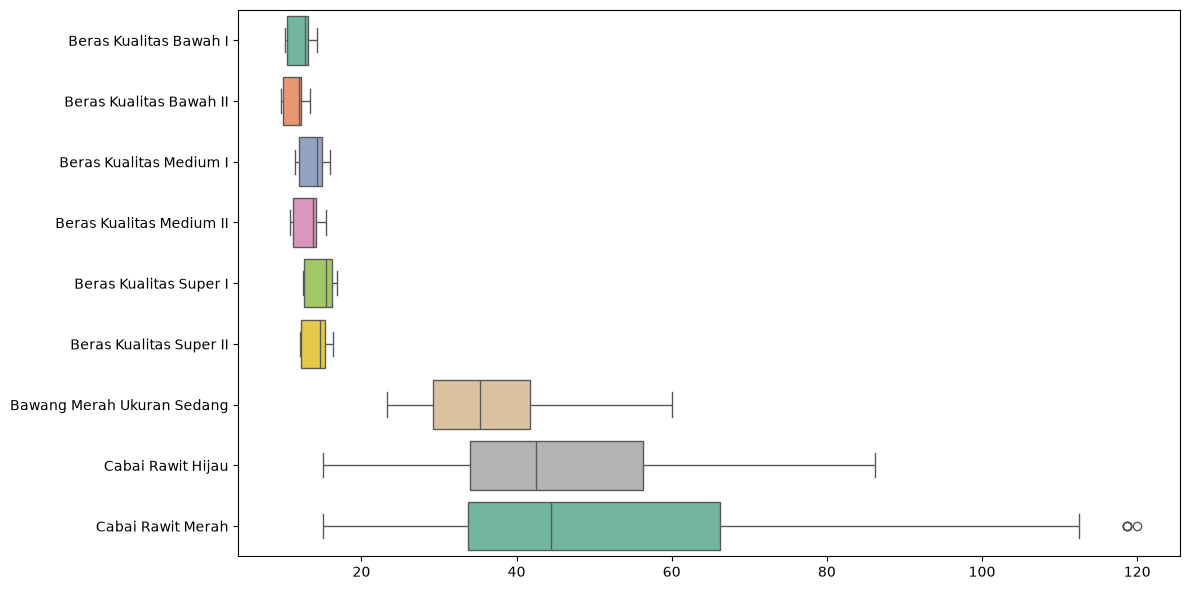

In [6]:
nums_cols = df_raw.select_dtypes(include="number").columns

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_raw[nums_cols], orient="h", palette="Set2", showfliers=True, whis=1.5
)
plt.tight_layout()
plt.show()

### 2.5 Matriks Korelasi

Heatmap korelasi antar komoditas untuk melihat seberapa searah pergerakan harganya.


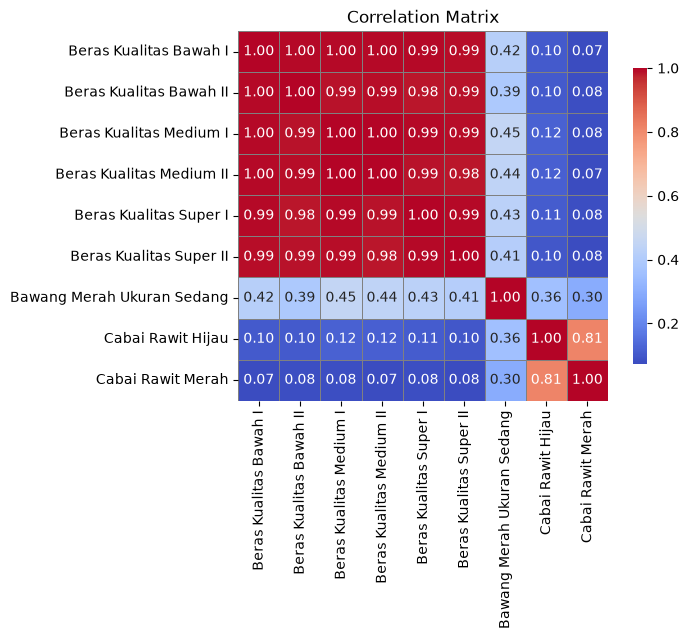

In [7]:
matrix_corr = df_raw[nums_cols].corr()
sns.heatmap(
    matrix_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.8},
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Correlation Matrix")
plt.show()

### 2.6 Memeriksa Missing Value (Heatmap)

Memetakan posisi nilai kosong untuk melihat apakah gap tersebar acak atau menumpuk pada periode tertentu.


<Axes: ylabel='tanggal'>

<Axes: ylabel='tanggal'>

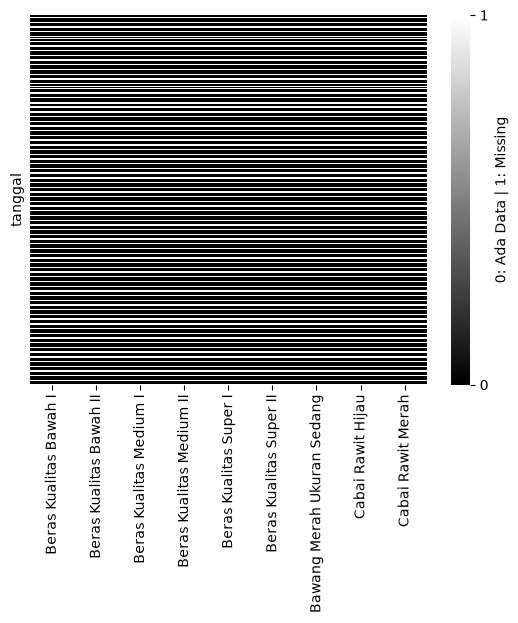

In [8]:
df_raw.isnull().sum()

sns.heatmap(
    df_raw.isnull(),
    cbar=True,
    yticklabels=False,
    cmap="binary_r",
    cbar_kws={"ticks": [0, 1], "label": "0: Ada Data | 1: Missing"},
)

### 2.7 Memeriksa Persentase Missing Value

Menghitung proporsi nilai kosong tiap kolom sebagai dasar pemilihan metode imputasi.


In [9]:
percentages = (df_raw.isnull().sum() / len(df_raw)) * 100
print(percentages)

Beras Kualitas Bawah I        29.980373
Beras Kualitas Bawah II       29.980373
Beras Kualitas Medium I       29.980373
Beras Kualitas Medium II      29.980373
Beras Kualitas Super I        29.980373
Beras Kualitas Super II       29.980373
Bawang Merah Ukuran Sedang    29.980373
Cabai Rawit Hijau             29.980373
Cabai Rawit Merah             29.980373
dtype: float64


## 3. Penanganan Missing Value dengan Interpolasi

Gap diisi dengan interpolasi berbasis waktu agar tren lokal tetap terjaga dan jumlah baris tidak berkurang.


### 3.1 Interpolasi Berbasis Waktu

`method="time"` mengisi gap secara proporsional terhadap jarak antar tanggal, bukan dengan satu nilai statis seperti mean.


In [10]:
feature_interpolation = df_raw.interpolate(
    method="time", limit_direction="forward", axis=0
)

### 3.2 Menetapkan `df_cleaned` dan Memeriksa Missing Value

Hasil interpolasi ditetapkan sebagai `df_cleaned`, lalu jumlah nilai kosongnya dicek ulang.


In [11]:
df_cleaned = feature_interpolation
print(df_cleaned.isnull().sum())

Beras Kualitas Bawah I        0
Beras Kualitas Bawah II       0
Beras Kualitas Medium I       0
Beras Kualitas Medium II      0
Beras Kualitas Super I        0
Beras Kualitas Super II       0
Bawang Merah Ukuran Sedang    0
Cabai Rawit Hijau             0
Cabai Rawit Merah             0
dtype: int64


### 3.3 Memeriksa Persentase Missing Value Setelah Interpolasi

Verifikasi bahwa persentase nilai kosong sudah 0% di seluruh kolom.


In [12]:
feature_miss_value = df_cleaned.isnull().sum() * 100 / len(df_cleaned)
print(feature_miss_value)

Beras Kualitas Bawah I        0.0
Beras Kualitas Bawah II       0.0
Beras Kualitas Medium I       0.0
Beras Kualitas Medium II      0.0
Beras Kualitas Super I        0.0
Beras Kualitas Super II       0.0
Bawang Merah Ukuran Sedang    0.0
Cabai Rawit Hijau             0.0
Cabai Rawit Merah             0.0
dtype: float64


### 3.4 Visualisasi Missing Value Setelah Interpolasi (Heatmap)

Konfirmasi visual bahwa tidak ada lagi nilai kosong yang tersisa.


<Axes: ylabel='tanggal'>

<Axes: ylabel='tanggal'>

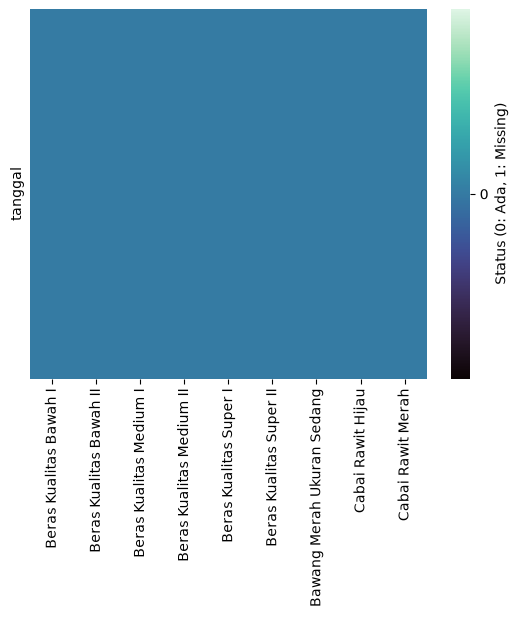

In [13]:
sns.heatmap(
    df_cleaned.isnull(),
    yticklabels=False,
    cmap="mako",
    cbar=True,
    cbar_kws={"ticks": [0, 1], "label": "Status (0: Ada, 1: Missing)"},
)

## 4. Uji Stasioneritas (ADF Test)

Augmented Dickey-Fuller test untuk menentukan apakah deret harga sudah stasioner. H0 (deret non-stasioner) ditolak bila p-value < 0.05. Hasil uji ini menjadi dasar keputusan detrending di bab 5.


### 4.1 Menentukan Daftar Kolom Komoditas

Menyimpan nama kolom ketiga komoditas ke `comodity_cols` untuk dipakai berulang di tahap-tahap berikutnya.


In [14]:
comodity_cols = df_cleaned.columns.tolist()

### 4.2 ADF Test dengan Trend dan Konstanta (`regression="ct"`)

Menguji stasioneritas dengan menyertakan konstanta dan tren deterministik (hipotesis _trend-stationary_).


In [15]:
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="ct",
        autolag="AIC",
        store=False,
        regresults=False,
    )

    print(f"ADF Statistic for {col}: {result[0]}")
    print(f"p-value for {col}: {result[1]}")
    if len(result) > 4:
        critical_values = result[4]
        print("Critical Values for: ")
        for key, value in critical_values.items():
            print(f"\t{key}: {value}")
    else:
        critical_values = {}
    status = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    print(f"status : {status}")
    print("\n")

ADF Statistic for Beras Kualitas Bawah I: -1.1808364979181052
p-value for Beras Kualitas Bawah I: 0.9143563466248097
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualitas Bawah II: -1.0090015757094468
p-value for Beras Kualitas Bawah II: 0.9428908749250071
Critical Values for: 
	1%: -3.9632321666575834
	5%: -3.412652823739877
	10%: -3.128323394200126
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium I: -1.6561424262773168
p-value for Beras Kualitas Medium I: 0.7696836037691607
Critical Values for: 
	1%: -3.963278836113111
	5%: -3.4126754323752686
	10%: -3.1283367017897814
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium II: -1.3309686501722258
p-value for Beras Kualitas Medium II: 0.880054924410183
Critical Values for: 
	1%: -3.9632365697022998
	5%: -3.4126549567695705
	10%: -3.1283246497184187
status : Non-Stationary


ADF Statistic for Beras Kualitas

### 4.3 ADF Test dengan Konstanta Saja (`regression="c"`)

Pengujian ulang dengan konstanta saja, sebagai pembanding hasil 4.2.


In [16]:
for col in comodity_cols:
    result = adfuller(
        df_cleaned[col].dropna(),
        maxlag=None,
        regression="c",
        autolag="AIC",
        store=False,
        regresults=False,
    )
    print(f"ADF Statistic for {col}: {result[0]}")
    print(f"p-value for {col}: {result[1]}")
    print("Critical Values:")
    if len(result) > 4:
        critical_values = result[4]
        for key, value in critical_values.items():
            print(f"\t{key}: {value}")
    else:
        critical_values = {}
    status = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    print(f"status : {status}")
    print("\n")

ADF Statistic for Beras Kualitas Bawah I: -0.9004045400756215
p-value for Beras Kualitas Bawah I: 0.7878391676235649
Critical Values:
	1%: -3.4335754129266802
	5%: -2.862964825335276
	10%: -2.567528514159528
status : Non-Stationary


ADF Statistic for Beras Kualitas Bawah II: -0.9770298432077914
p-value for Beras Kualitas Bawah II: 0.7615496824458818
Critical Values:
	1%: -3.4335722342837056
	5%: -2.862963421928457
	10%: -2.567527766920221
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium I: -1.0959940916817663
p-value for Beras Kualitas Medium I: 0.7166667683120853
Critical Values:
	1%: -3.433605925774539
	5%: -2.862978297026843
	10%: -2.5675356871295394
status : Non-Stationary


ADF Statistic for Beras Kualitas Medium II: -1.0730587916027134
p-value for Beras Kualitas Medium II: 0.7256953192293748
Critical Values:
	1%: -3.4335754129266802
	5%: -2.862964825335276
	10%: -2.567528514159528
status : Non-Stationary


ADF Statistic for Beras Kualitas Super I: -0.73082668207

## 5. Detrending dan Deseasonalization dengan Dekomposisi MSTL

MSTL memisahkan tiap deret menjadi komponen trend, musiman mingguan (period 7), musiman tahunan (period 365), dan residual. Pemodelan dilakukan di level residual yang sudah bebas tren dan pola musiman.


### 5.1 Mendekomposisi Trend, Seasonal, dan Residual Setiap Komoditas

Dekomposisi MSTL (mode `robust`) untuk tiap komoditas; komponen hasilnya disimpan sebagai kolom baru pada `df_cleaned`. Komponen trend diaproksimasi dengan regresi linier terhadap `time_index` agar bisa diekstrapolasi saat rekonstruksi harga.


In [17]:
df_cleaned["time_index"] = np.arange(len(df_cleaned))
trend_models = {}
stl_results = {}

paras_mstl = {
    "periods": [7, 365],
    "windows": [7, 365],
    "stl_kwargs": {"robust": True},
}

for col in comodity_cols:
    mstl = MSTL(df_cleaned[col], **paras_mstl).fit()
    stl_results[col] = mstl

    df_cleaned[f"{col}_trend"] = mstl.trend.values
    df_cleaned[f"{col}_seasonal_weekly"] = mstl.seasonal["seasonal_7"].values
    df_cleaned[f"{col}_seasonal_yearly"] = mstl.seasonal["seasonal_365"].values
    df_cleaned[f"{col}_residual"] = mstl.resid.values

    tm = LinearRegression()
    tm.fit(df_cleaned[["time_index"]], df_cleaned[f"{col}_trend"])
    trend_models[col] = tm

### 5.2 Menyimpan Model Trend dan Hasil MSTL

`trend_models.pkl` dan `stl_results.pkl` disimpan supaya tahap rekonstruksi dan inference tidak perlu menjalankan ulang dekomposisi MSTL dari awal.


In [38]:
jl.dump(trend_models, "models/trend_models.pkl")
jl.dump(stl_results, "models/stl_results.pkl")

['models/stl_results.pkl']

## 6. Feature Engineering (Fitur Lag dan Rolling)

Seluruh fitur dibangun di level residual: fitur lag, statistik rolling, fitur kalender, lalu target multi-horizon.


### 6.1 Fitur Lag, Statistik Rolling, dan Fitur Kalender

Lag 1, 7, 14, dan 30 hari serta statistik rolling (mean, std, min, max) pada window 7 dan 30 hari dari kolom residual, ditambah fitur kalender: `day_of_week` dan encoding siklik bulan (`month_sin`, `month_cos`) agar Desember dan Januari terbaca berdekatan oleh model. Transformer-nya disimpan ke `features_transformers.pkl` supaya definisi fitur saat inference persis sama dengan saat training.


In [39]:
lag_features = [1, 7, 14, 30]
windows_features = [7, 30]

features_transformers = {}
df_features = df_cleaned.copy()

for col in comodity_cols:
    lag_transformer = LagFeatures(
        variables=[f"{col}_residual"],
        periods=lag_features,
        missing_values="ignore",
    )
    window_transformer = WindowFeatures(
        variables=[f"{col}_residual"],
        window=windows_features,
        functions=["mean", "std", "min", "max"],
        missing_values="ignore",
        freq="D",
    )

    df_features = lag_transformer.fit_transform(df_features)
    df_features = window_transformer.fit_transform(df_features)
    features_transformers[col] = {"lags": lag_transformer, "window": window_transformer}

df_features["day_of_week"] = df_features.index.dayofweek  # pyright: ignore[reportAttributeAccessIssue]
df_features["month_sin"] = np.sin(2 * np.pi * df_features.index.month / 12)  # pyright: ignore[reportAttributeAccessIssue]
df_features["month_cos"] = np.cos(2 * np.pi * df_features.index.month / 12)  # pyright: ignore[reportAttributeAccessIssue]

jl.dump(features_transformers, "models/features_transformers.pkl")

['models/features_transformers.pkl']

### 6.2 Fungsi Pemilihan Kolom Fitur

`feature_cols_for(col)` mengumpulkan kolom fitur milik satu komoditas ditambah fitur kalender, sehingga tiap model hanya memakai fitur dari komoditasnya sendiri.


In [20]:
def feature_cols_for(col):
    lag_windows_cols = [
        c
        for c in df_features.columns
        if c.startswith(f"{col}_residual_lag_")  # pyright: ignore[reportAttributeAccessIssue]
    ]
    calendar_cols = ["day_of_week", "month_sin", "month_cos"]
    return lag_windows_cols + calendar_cols

### 6.3 Fitur Lag Horizontal (Multi-step Forecasting)

Target dibentuk dengan menggeser residual ke depan sebanyak `h` hari untuk h = 1, 7, dan 30 (strategi _direct multi-step_: satu model terpisah untuk tiap horizon).


In [21]:
horizontal_features = [1, 7, 30]

for col in comodity_cols:
    for h in horizontal_features:
        df_features[f"{col}_target_h{h}"] = df_features[f"{col}_residual"].shift(-h)  # pyright: ignore[reportAttributeAccessIssue]

### 6.4 Menyusun Matriks Fitur (X) dan Target (y)

Menggabungkan kolom fitur dengan satu kolom target, membuang baris NaN yang muncul akibat lag dan shift, lalu memisahkannya menjadi `X` dan `y`.


In [22]:
cols_needed = feature_cols_for(col) + [f"{col}_target_h{h}"]
data = df_features[cols_needed].dropna()

X = data[feature_cols_for(col)]
y = data[f"{col}_target_h{h}"]

## 7. Optimasi Hyperparameter LightGBM dengan Genetic Algorithm

Genetic Algorithm mencari kombinasi hyperparameter LightGBM terbaik untuk setiap pasangan komoditas × horizon.


### 7.1 Fitness Function dan Konfigurasi GA (PyGAD)

Fitness dihitung dari rata-rata RMSE 10-fold cross validation dan dinegasikan, karena GA bekerja dengan memaksimalkan nilai fitness. Konfigurasi GA: 30 generasi, populasi 40 individu, seleksi _tournament_ (K=5), _single-point crossover_, mutasi adaptif, dan elitisme 2, dengan 11 gen yang mewakili hyperparameter LightGBM.


In [ ]:
from numpy import _2D


def fitness_function(params, X, y):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    rmse_scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = lgb.LGBMRegressor(**params, verbose=-1, n_jobs=-1)
        model.fit(
            X_train,
            y_train,
            eval_X=X_test,
            eval_y=y_test,
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
        )
        pred = model.predict(X_test)
        rmse_scores.append(root_mean_squared_error(y_test, pred))
    return np.mean(rmse_scores)


def fitness_func_pygad(ga_instance, solution, solution_idx):
    params = {
        "boosting_type": "goss",
        "num_leaves": int(solution[0]),
        "max_depth": int(solution[1]),
        "learning_rate": solution[2],
        "n_estimators": int(solution[3]),
        "sub_sample_for_bin": int(solution[4]),
        "objective": "regression",
        "class_weight": ["balanced", None],
        "min_split_gain": solution[5],
        "min_child_weight": solution[5],
        "min_child_samples": int(solution[7]),
        "subsample": solution[8],
        "subsample_freq": solution[9],
        "colsample_bytree": solution[10],
        "reg_alpha": solution[11],
        "reg_lambda": solution[12],
        "bagging_freq": 1,
    }
    rmse = fitness_function(params, X, y)
    return -rmse


def run_for_ga(X, y):
    genetic_algorithm_instance = pygad.GA(
        num_generations=15,
        num_parents_mating=15,
        sol_per_pop=30,
        fitness_func=fitness_func_pygad,
        num_genes=13,
        mutation_percent_genes=[20, 5],
        gene_space=[
            {"low": 10, "high": 1000},  # num_leaves
            {"low": 1, "high": 15},  # max_depth
            {"low": 0.001, "high": 0.3},  # learning_rate
            {"low": 50, "high": 1000},  # n_estimators
            {"low": 100, "high": 10000},  # sub_sample_for_bin
            {"low": 0.0, "high": 1.0},  # min_split_gain
            {"low": 0.0, "high": 10.0},  # min_child_weight
            {"low": 1, "high": 1000},  # min_child_samples
            {"low": 0.1, "high": 1.0},  # subsample
            {"low": 0, "high": 10},  # subsample_freq
            {"low": 0.1, "high": 1.0},  # colsample_bytree
            {"low": 0.0, "high": 1.0},  # reg_alpha
            {"low": 0.0, "high": 1.0},  # reg_lambda
        ],
        gene_type=float,
        parent_selection_type="tournament",
        K_tournament=5,
        crossover_type="single_point",
        crossover_probability=0.9,
        mutation_type="adaptive",
        keep_elitism=2,
        on_generation=on_generation,
        parallel_processing=["thread", None],
    )
    genetic_algorithm_instance.run()
    best_solution, best_solution_fitness, best_solution_idx = (
        genetic_algorithm_instance.best_solution()
    )
    return best_solution, genetic_algorithm_instance


def on_generation(ga_instance):
    best_fitness = np.max(ga_instance.last_generation_fitness)
    print(f"Generation : {ga_instance.generations_completed}")
    print(f"RMSE : {-best_fitness:.4f}")
    print("--------------------------------------------------")


best_params_from_GA = {}
for col in comodity_cols:
    best_params_from_GA[col] = {}
    for h in horizontal_features:
        target_col = f"{col}_target_h{h}"
        model_data = df_features[feature_cols_for(col) + [target_col]].dropna()
        X = model_data[feature_cols_for(col)]
        y = model_data[target_col]
        best_solution, ga_instance = run_for_ga(X, y)

        best_params_from_GA[col][h] = {
            "num_leaves": int(best_solution[0]),
            "max_depth": int(best_solution[1]),
            "learning_rate": best_solution[2],
            "n_estimators": int(best_solution[3]),
            "sub_sample_for_bin": int(best_solution[4]),
            "min_split_gain": best_solution[5],
            "min_child_weight": best_solution[6],
            "min_child_samples": int(best_solution[7]),
            "subsample": best_solution[8],
            "subsample_freq": int(best_solution[9]),
            "colsample_bytree": best_solution[10],
            "reg_alpha": best_solution[11],
            "reg_lambda": best_solution[12],
            "bagging_freq": 1,
        }

d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM SKRIPSI\.venv\Lib\site-packages\pygad\utils\validation.py:1012: UserWarning: The percentage of genes to mutate (5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate ({mutation_percent_genes[idx]}) resulted in selecting ({mutation_num_genes[idx]}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM SKRIPSI\.venv\Lib\site-packages\pygad\utils\validation.py:1012: UserWarning: The percentage of genes to mutate (5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate ({mutation_percent_genes[idx]}) resulted in selecting ({mutation_num_genes[idx]}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Generation : 1
RMSE : 0.0720
--------------------------------------------------
Generation : 2
RMSE : 0.0701
--------------------------------------------------
Generation : 3
RMSE : 0.0682
--------------------------------------------------
Generation : 4
RMSE : 0.0663
--------------------------------------------------
Generation : 5
RMSE : 0.0661
--------------------------------------------------
Generation : 6
RMSE : 0.0646
--------------------------------------------------
Generation : 7
RMSE : 0.0634
--------------------------------------------------
Generation : 8
RMSE : 0.0605
--------------------------------------------------
Generation : 9
RMSE : 0.0590
--------------------------------------------------
Generation : 10
RMSE : 0.0583
--------------------------------------------------
Generation : 11
RMSE : 0.0583
--------------------------------------------------
Generation : 12
RMSE : 0.0583
--------------------------------------------------
Generation : 13
RMSE : 0.0581
-------

d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM SKRIPSI\.venv\Lib\site-packages\pygad\utils\validation.py:1012: UserWarning: The percentage of genes to mutate (5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate ({mutation_percent_genes[idx]}) resulted in selecting ({mutation_num_genes[idx]}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Generation : 1
RMSE : 0.0720
--------------------------------------------------
Generation : 2
RMSE : 0.0701
--------------------------------------------------
Generation : 3
RMSE : 0.0682
--------------------------------------------------
Generation : 4
RMSE : 0.0663
--------------------------------------------------
Generation : 5
RMSE : 0.0661
--------------------------------------------------
Generation : 6
RMSE : 0.0646
--------------------------------------------------
Generation : 7
RMSE : 0.0634
--------------------------------------------------
Generation : 8
RMSE : 0.0605
--------------------------------------------------
Generation : 9
RMSE : 0.0590
--------------------------------------------------
Generation : 10
RMSE : 0.0583
--------------------------------------------------
Generation : 11
RMSE : 0.0583
--------------------------------------------------
Generation : 12
RMSE : 0.0583
--------------------------------------------------
Generation : 13
RMSE : 0.0581
-------

...

Generation : 1
RMSE : 5.8819
--------------------------------------------------
Generation : 2
RMSE : 5.8819
--------------------------------------------------
Generation : 3
RMSE : 5.8819
--------------------------------------------------
Generation : 4
RMSE : 5.8790
--------------------------------------------------
Generation : 5
RMSE : 5.8790
--------------------------------------------------
Generation : 6
RMSE : 5.8572
--------------------------------------------------
Generation : 7
RMSE : 5.8522
--------------------------------------------------
Generation : 8
RMSE : 5.8436
--------------------------------------------------
Generation : 9
RMSE : 5.8436
--------------------------------------------------
Generation : 10
RMSE : 5.8436
--------------------------------------------------
Generation : 11
RMSE : 5.8436
--------------------------------------------------
Generation : 12
RMSE : 5.8436
--------------------------------------------------
Generation : 13
RMSE : 5.8436
-------

d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM SKRIPSI\.venv\Lib\site-packages\pygad\utils\validation.py:1012: UserWarning: The percentage of genes to mutate (5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate ({mutation_percent_genes[idx]}) resulted in selecting ({mutation_num_genes[idx]}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Generation : 1
RMSE : 7.8606
--------------------------------------------------
Generation : 2
RMSE : 7.7893
--------------------------------------------------
Generation : 3
RMSE : 7.7673
--------------------------------------------------
Generation : 4
RMSE : 7.6136
--------------------------------------------------
Generation : 5
RMSE : 7.6133
--------------------------------------------------
Generation : 6
RMSE : 7.5980
--------------------------------------------------
Generation : 7
RMSE : 7.5865
--------------------------------------------------
Generation : 8
RMSE : 7.5586
--------------------------------------------------
Generation : 9
RMSE : 7.5586
--------------------------------------------------
Generation : 10
RMSE : 7.5497
--------------------------------------------------
Generation : 11
RMSE : 7.5438
--------------------------------------------------
Generation : 12
RMSE : 7.5438
--------------------------------------------------
Generation : 13
RMSE : 7.4886
-------

d:\PR DAN SEBAGAINYA TENTANG KAMPUS\SEMESTER 7 SKIRPSI\PROGRAM SKRIPSI\.venv\Lib\site-packages\pygad\utils\validation.py:1012: UserWarning: The percentage of genes to mutate (5) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(f"The percentage of genes to mutate ({mutation_percent_genes[idx]}) resulted in selecting ({mutation_num_genes[idx]}) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).\nIf you do not want to mutate any gene, please set mutation_type=None.")


Generation : 1
RMSE : 9.7068
--------------------------------------------------
Generation : 2
RMSE : 9.3013
--------------------------------------------------
Generation : 3
RMSE : 9.2578
--------------------------------------------------
Generation : 4
RMSE : 9.1898
--------------------------------------------------
Generation : 5
RMSE : 9.1743
--------------------------------------------------
Generation : 6
RMSE : 9.1743
--------------------------------------------------
Generation : 7
RMSE : 9.1443
--------------------------------------------------
Generation : 8
RMSE : 9.1091
--------------------------------------------------
Generation : 9
RMSE : 9.1091
--------------------------------------------------
Generation : 10
RMSE : 9.1091
--------------------------------------------------
Generation : 11
RMSE : 9.1091
--------------------------------------------------
Generation : 12
RMSE : 9.0969
--------------------------------------------------
Generation : 13
RMSE : 9.0969
-------

### 7.2 Menampilkan Hyperparameter Terbaik per Komoditas dan Horizon

Bagian ini menampilkan hasil `best_params_from_GA` untuk setiap komoditas pada horizon 1, 7, dan 30 hari agar konfigurasi model terbaik mudah dibaca sebelum tahap evaluasi visual.


In [32]:
for commodity, params_h in best_params_from_GA.items():
    print("\n" + "-" * 72)
    print(f"Nama Komoditas: {commodity}")
    print("-" * 72)

    for h in horizontal_features:
        p = params_h[h]
        print(f"\nHorizon: {h} hari")
        print("-" * 72)
        for key, value in p.items():
            if isinstance(value, float):
                print(f"{key:20s}: {value:.6f}")
            else:
                print(f"{key:20s}: {value}")


------------------------------------------------------------------------
Nama Komoditas: Beras Kualitas Bawah I
------------------------------------------------------------------------

Horizon: 1 hari
------------------------------------------------------------------------
num_leaves          : 918
learning_rate       : 0.079058
max_depth           : 12
n_estimators        : 500
min_child_samples   : 1
subsample           : 0.770880
colsample_bytree    : 0.922422
min_child_weight    : 0.936521
reg_alpha           : 0.214296
reg_lambda          : 1.661401
min_split_gain      : 0.004836
bagging_freq        : 1

Horizon: 7 hari
------------------------------------------------------------------------
num_leaves          : 523
learning_rate       : 0.187071
max_depth           : 9
n_estimators        : 827
min_child_samples   : 5
subsample           : 0.828241
colsample_bytree    : 0.842907
min_child_weight    : 3.312981
reg_alpha           : 0.684898
reg_lambda          : 7.017265
min_sp

### 7.3 Visualisasi Progres Optimasi (RMSE per Generasi)

Kurva pada bagian ini menunjukkan perubahan nilai RMSE terbaik selama proses Genetic Algorithm. Karena metrik yang dipakai adalah error, nilai yang menurun menandakan performa model semakin baik.


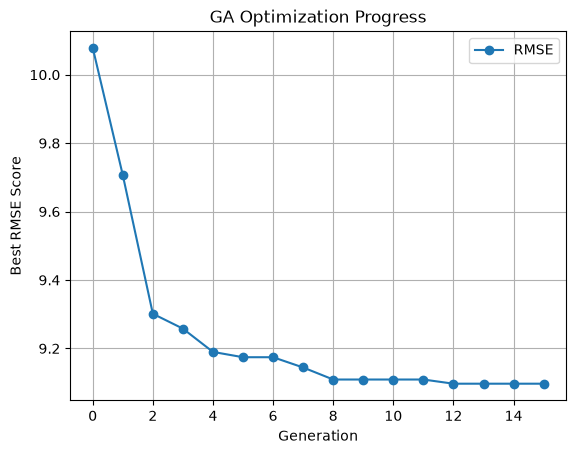

In [41]:
rmse_params = [-rmse_history for rmse_history in ga_instance.best_solutions_fitness]


plt.plot(rmse_params, marker="o", linestyle="-")
plt.legend(["RMSE"])
plt.xlabel("Generation")
plt.ylabel("Best RMSE Score")
plt.title("GA Optimization Progress")
plt.grid(True)
plt.show()

### 7.4 Menyimpan Hasil Hyperparameter

Hyperparameter terbaik disimpan ke file `best_params_from_GA.pkl` agar dapat digunakan kembali pada sesi berikutnya tanpa menjalankan optimasi GA dari awal.


In [42]:
BEST_PARAMS_PATH = "best_params_from_GA.pkl"

jl.dump(best_params_from_GA, f"models/{BEST_PARAMS_PATH}")
print(f"Best parameters saved to models/{BEST_PARAMS_PATH}")


Best parameters saved to models/best_params_from_GA.pkl
